In [9]:
from collections import defaultdict

from PIL import Image
from IPython.display import display

import re
def extract_answer(output_text, tag="answer"):
    match = re.search(rf"<{tag}>\s*(.*?)\s*</{tag}>", output_text, re.DOTALL)
    return match.group(1).strip() if match else None

## Load the model

In [10]:
import os
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, GenerationConfig
from qwen_vl_utils import process_vision_info
from importlib.util import find_spec
import torch


os.environ["HF_HOME"] = "/data/huggingface_cache"
MODEL_PATH = "JZPeterPan/MedVLM-R1"

cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"
print(f"Using device: {device}")

flash_attn_available = find_spec("flash_attn") is not None
attn_implementation = "flash_attention_2" if flash_attn_available else "sdpa"
print(f"Using attention implementation: {attn_implementation}")

dtype = torch.bfloat16 if cuda_available else torch.float32
print(f"Using dtype: {dtype}")

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    dtype=dtype,
    attn_implementation=attn_implementation,
    device_map="auto",
)
model.eval()
model.requires_grad_(False)
model.config.use_cache = False

processor = AutoProcessor.from_pretrained(MODEL_PATH)
image_processor = processor.image_processor

generation_config = GenerationConfig(
    max_new_tokens=1024,
    do_sample=False,  
    temperature=1, 
    num_return_sequences=1,
    pad_token_id=151643,
)

print("Model and processor loaded successfully.")


Using device: cuda
Using attention implementation: sdpa
Using dtype: torch.bfloat16
Model and processor loaded successfully.


## Load VQA examples

In [11]:
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg


# question = {"image": ['images/successful_cases/mdb146.png'], "problem": "What content appears in this image?\nA) Cardiac tissue\nB) Breast tissue\nC) Liver tissue\nD) Skin tissue", "solution": "B", "answer": "Breast tissue"}

# # question = {"image": ["images/successful_cases/person19_virus_50.jpeg"], "problem": "What content appears in this image?\nA) Lungs\nB) Bladder\nC) Brain\nD) Heart", "solution": "A", "answer": "Lungs"}

# # question = {"image":["images/successful_cases/abd-normal023599.png"],"problem":"Is any abnormality evident in this image?\nA) No\nB) Yes.","solution":"A","answer":"No"}

# # question = {"image":["images/successful_cases/foot089224.png"],"problem":"Which imaging technique was utilized for acquiring this image?\nA) MRI\nB) Electroencephalogram (EEG)\nC) Ultrasound\nD) Angiography","solution":"A","answer":"MRI"}

# # question = {"image":["images/successful_cases/knee031316.png"],"problem":"What can be observed in this image?\nA) Chondral abnormality\nB) Bone density loss\nC) Synovial cyst formation\nD) Ligament tear","solution":"A","answer":"Chondral abnormality"}

# # question = {"image":["images/successful_cases/shoulder045906.png"],"problem":"What can be visually detected in this picture?\nA) Bone fracture\nB) Soft tissue fluid\nC) Blood clot\nD) Tendon tear","solution":"B","answer":"Soft tissue fluid"}

# # question = {"image":["images/successful_cases/brain003631.png"],"problem":"What attribute can be observed in this image?\nA) Focal flair hyperintensity\nB) Bone fracture\nC) Vascular malformation\nD) Ligament tear","solution":"A","answer":"Focal flair hyperintensity"}

# # question = {"image":["images/successful_cases/mrabd005680.png"],"problem":"What can be observed in this image?\nA) Pulmonary embolism\nB) Pancreatic abscess\nC) Intraperitoneal mass\nD) Cardiac tamponade","solution":"C","answer":"Intraperitoneal mass"}

# print(question["problem"], '\nGroundtruth Solution:',question["solution"])

# img = mpimg.imread(question["image"][0])
# plt.imshow(img, cmap='gray')
# plt.show()

# Original questions
all_questions = [
    # {"image": ["data/MedVLM-R1/images/mdb146.png"], "problem": "What content appears in this image?\nA) Cardiac tissue\nB) Breast tissue\nC) Liver tissue\nD) Skin tissue", "solution": "B", "answer": "Breast tissue"},
    # {"image": ["data/MedVLM-R1/images/person19_virus_50.jpeg"], "problem": "What content appears in this image?\nA) Lungs\nB) Bladder\nC) Brain\nD) Heart", "solution": "A", "answer": "Lungs"},
    # {"image": ["data/MedVLM-R1/images/abd-normal023599.png"], "problem": "Is any abnormality evident in this image?\nA) No\nB) Yes.", "solution": "A", "answer": "No"},
    # {"image": ["data/MedVLM-R1/images/foot089224.png"], "problem": "Which imaging technique was utilized for acquiring this image?\nA) MRI\nB) Electroencephalogram (EEG)\nC) Ultrasound\nD) Angiography", "solution": "A", "answer": "MRI"},
    # {"image": ["data/MedVLM-R1/images/knee031316.png"], "problem": "What can be observed in this image?\nA) Chondral abnormality\nB) Bone density loss\nC) Synovial cyst formation\nD) Ligament tear", "solution": "A", "answer": "Chondral abnormality"},
    # {"image": ["data/MedVLM-R1/images/shoulder045906.png"], "problem": "What can be visually detected in this picture?\nA) Bone fracture\nB) Soft tissue fluid\nC) Blood clot\nD) Tendon tear", "solution": "B", "answer": "Soft tissue fluid"},
    # {"image": ["data/MedVLM-R1/images/brain003631.png"], "problem": "What attribute can be observed in this image?\nA) Focal flair hyperintensity\nB) Bone fracture\nC) Vascular malformation\nD) Ligament tear", "solution": "A", "answer": "Focal flair hyperintensity"},
    # {"image": ["data/MedVLM-R1/images/mrabd005680.png"], "problem": "What can be observed in this image?\nA) Pulmonary embolism\nB) Pancreatic abscess\nC) Intraperitoneal mass\nD) Cardiac tamponade", "solution": "C", "answer": "Intraperitoneal mass"},
    
    {"image": ["data/OmniMedVQA/sample_mri/images/mod-mri_000000.png"], "problem": "What was the type of imaging modality utilized to obtain this image? A)Endoscopy, B)MRI, C)Ultrasound, D)Mammography", "solution": "B", "answer": "MRI"},
    {"image": ["result/MedVLM-R1/bias_field_attack/cps_8_eps_0p3/batch_0/attacked_images/mod-mri_000000_biased.png"], "problem": "What was the type of imaging modality utilized to obtain this image? A)Endoscopy, B)MRI, C)Ultrasound, D)Mammography", "solution": "B", "answer": "MRI"},

]

## Run the inference 

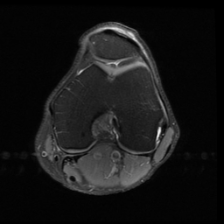

What was the type of imaging modality utilized to obtain this image? A)Endoscopy, B)MRI, C)Ultrasound, D)Mammography
Model Answer: B
Model Thought: The image appears to be a cross-sectional view of a human body, likely obtained using an MRI (Magnetic Resonance Imaging) scan. MRI scans are commonly used to visualize internal structures of the body, including bones, muscles, and soft tissues.
Groundtruth Solution: B


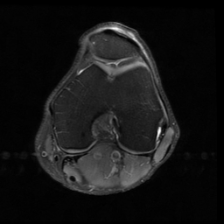

What was the type of imaging modality utilized to obtain this image? A)Endoscopy, B)MRI, C)Ultrasound, D)Mammography
Model Answer: D
Model Thought: The image appears to be a mammogram, which is a type of imaging modality used to detect abnormalities in the breast tissue.
Groundtruth Solution: B
Incorrect answer. Expected: B, but got: D

Final Score: 1/2


In [12]:
group_correct = defaultdict(lambda: True)

score = 0

for i, question in enumerate(all_questions):
    QUESTION_TEMPLATE = """
        {Question}
        Your task:
        1. Think through the question step by step, enclose your reasoning process in <think>...</think> tags.
        2. Then provide the correct single-letter choice (A, B, C, D,...) inside <answer>...</answer> tags.
        3. No extra information or text outside of these tags.
        """

    message = [{
        "role": "user",
        "content": [{"type": "image", "image": f"file://{question['image'][0]}"}, {"type": "text","text": QUESTION_TEMPLATE.format(Question=question['problem'])}]
    }]

    text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)

    image_inputs, video_inputs = process_vision_info(message)
    inputs = processor(
        text=text,
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(model.device)

    generated_ids = model.generate(**inputs, use_cache=True, max_new_tokens=1024, do_sample=False, generation_config=generation_config)

    generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]

    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
    
    display(Image.open(question["image"][0]))
    
    print(question["problem"])
    
    # print("model output:\n" + output_text[0])
    
    model_answer = extract_answer(output_text[0], tag="answer")
    model_thought = extract_answer(output_text[0], tag="think")
    
    print(f"Model Answer: \033[94m{model_answer}\033[0m")
    print(f"Model Thought: \033[94m{model_thought}\033[0m")
    print(f"\033[92mGroundtruth Solution: {question['solution']}\033[0m")
    
    if model_answer == question['solution']:
        score +=1
    else:
        print(f"\033[91mIncorrect answer. Expected: {question['solution']}, but got: {model_answer}\033[0m")
        
    group_key = question["image"][0]

    if model_answer != question["solution"]:
        group_correct[group_key] = False
        
print(f"\nFinal Score: {score}/{len(all_questions)}")